# Task 1: Exploring and Visualizing a Simple Dataset

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Problem Statement

Before building any machine learning model, an engineer first needs to
understand the shape, distributions, and relationships within their data.
This notebook practices that foundational skill using the classic **Iris**
dataset — a small, clean dataset perfect for learning data inspection and
visualization.

## Objective

- Load and inspect the Iris dataset with `pandas`.
- Summarize it with descriptive statistics.
- Visualize feature relationships, distributions, and outliers using
  `matplotlib` and `seaborn`.

## Dataset

**Iris Dataset** — 150 flower samples across 3 species (*setosa*,
*versicolor*, *virginica*), each described by 4 measurements: sepal length,
sepal width, petal length, and petal width. Loaded via `seaborn`'s built-in
dataset loader, with a local CSV copy (`iris.csv`) included for
reproducibility.


In [1]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Data Loading & Inspection

In [2]:
# Load the dataset using pandas (local CSV, originally sourced via seaborn)
df = pd.read_csv("iris.csv")

print("Shape of the dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
df.head()


Shape of the dataset: (150, 5)

Column names:
 ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# .info() — data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [4]:
# .describe() — summary statistics for numeric columns
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Check class balance and missing values
print("Species counts:\n", df["species"].value_counts())
print("\nMissing values per column:\n", df.isnull().sum())


Species counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


## 2. Visualization

### 2.1 Scatter plot — relationships between features

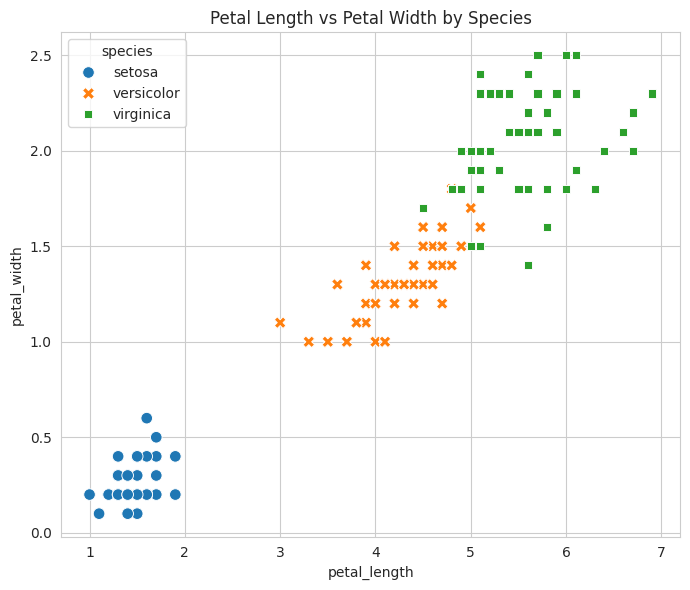

In [6]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue="species", style="species", s=70
)
plt.title("Petal Length vs Petal Width by Species")
plt.tight_layout()
plt.show()


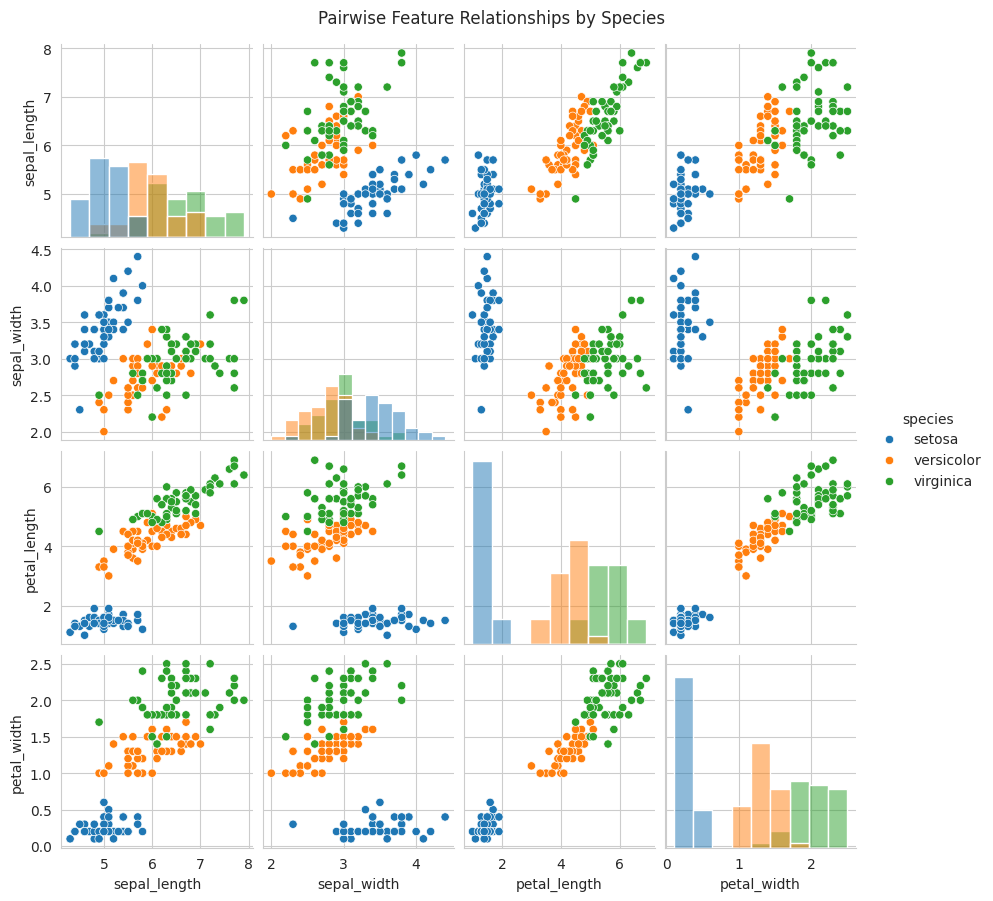

In [7]:
# Pairplot gives every pairwise feature relationship at once
sns.pairplot(df, hue="species", diag_kind="hist", height=2.2)
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()


### 2.2 Histograms — value distributions

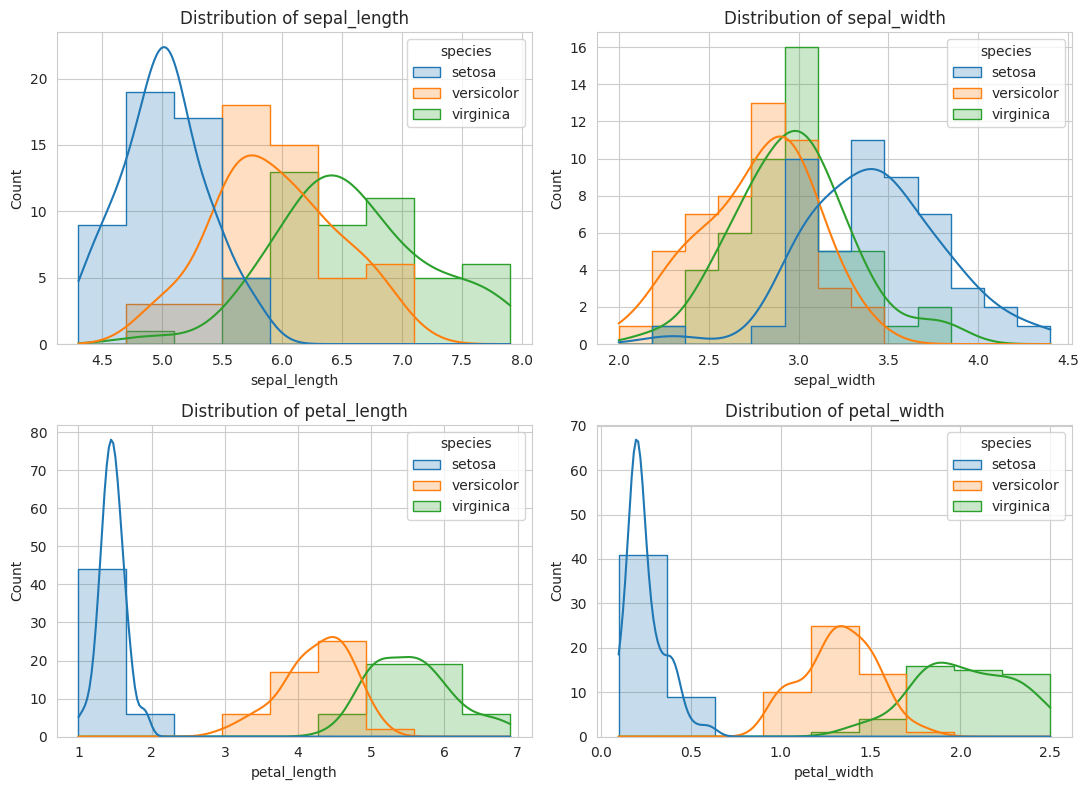

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feature, hue="species", kde=True, ax=ax, element="step")
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()


### 2.3 Box plots — spotting outliers

/tmp/ipykernel_859/2295860563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_859/2295860563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_859/2295860563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_859/2295860563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

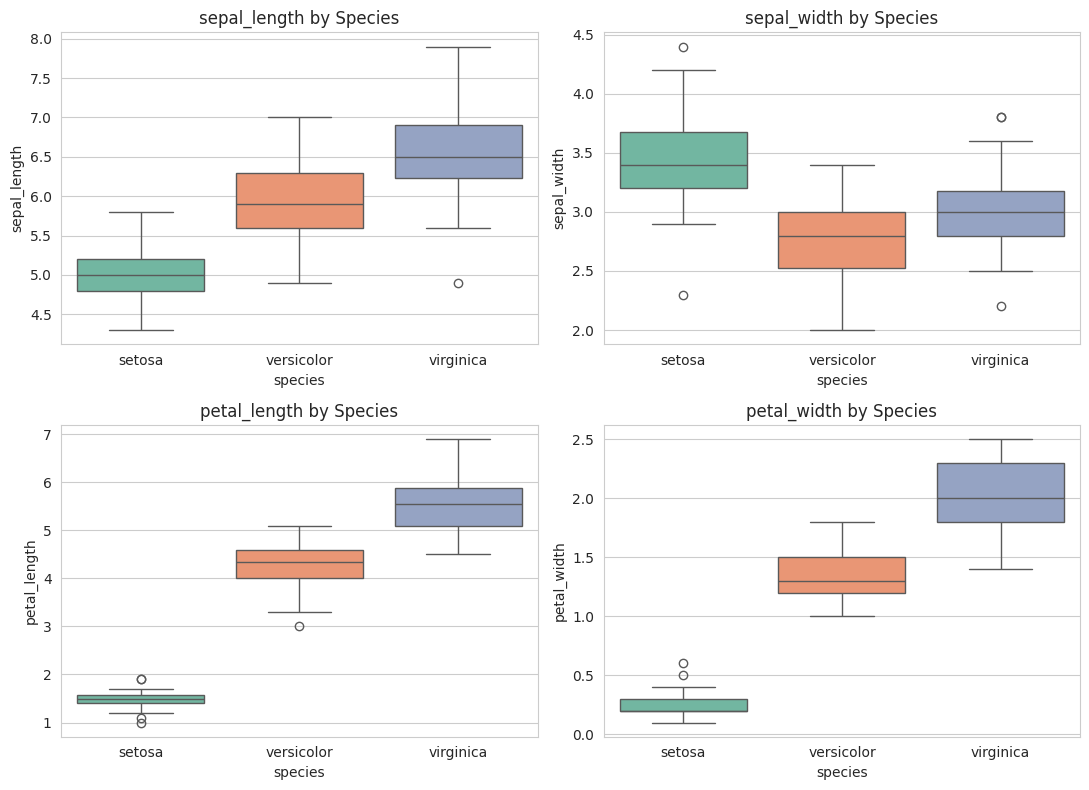

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
    ax.set_title(f"{feature} by Species")

plt.tight_layout()
plt.show()


## 3. Conclusion & Insights

- **Setosa** is clearly separated from the other two species on petal length
  and petal width — a simple threshold on either feature would classify it
  almost perfectly.
- **Versicolor** and **virginica** overlap more, especially on sepal
  measurements, but remain reasonably distinguishable on petal length/width.
- Petal measurements are far more discriminative between species than sepal
  measurements, which is useful to know before choosing features for any
  future classification model.
- Box plots show a few mild outliers in sepal width for *setosa*, but
  nothing extreme enough to warrant removal.
